<a href="https://colab.research.google.com/github/barbararolska/Wizualizacja-danych/blob/main/Laboratorium_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Wybory Prezydenckie 2025 (I Tura) – Radykalna Kartografia
---

Witaj na kolejnych zajęciach z wizualizacji danych! Dzisiaj połączymy twarde dane polityczne (wyniki I tury wyborów prezydenckich z PKW) z mapami przestrzennymi w pakiecie **Geopandas**.

Naszym przewodnikiem będzie William Rankin i jego książka **„Radical Cartography: How Changing Our Maps Can Change Our World”**. Autor zauważa, że tradycyjne mapy wyborcze to najwięksi kłamcy współczesnej kartografii.

Cierpią one na tzw. **Pułapkę Jurysdykcyjną (Jurisdictional Trap)**. Zamalowują całe powiaty jednym kolorem (*jigsaw-puzzle maps*), zmuszając nas do myślenia, że wielkie, zalesione i słabo zaludnione terytoria mają takie samo znaczenie jak gęsto zaludnione miasta. Tworzą też fałszywy, ostry podział na "Polskę A i Polskę B". Ziemia jednak nie głosuje – głosują ludzie!

**Podczas tych zajęć nauczymy się:**
1. Wczytywać i czyścić rzeczywiste dane wyborcze z PKW (naprawiając kody TERYT).
2. Tworzyć zaawansowaną galerię **Small Multiples** używając `plt.subplot_mosaic()`.
3. Agregować dane ideologicznie (Lewica, Centrum, Prawica).
4. Dekonstruować mapy (Makeover): przejdziemy od mylących kartogramów do map bąbelkowych (Bubble Maps), które niszczą iluzję terytorialną.

## Zadanie 1: Pobieranie i agregacja danych z I Tury, naprawa TERYT i Merge
---

Dzisiaj będziemy pracować na "twardych" plikach prosto od polskich instytucji państwowych. Zanim zaczniesz kodować, musisz zdobyć dane i wgrać je do wirtualnej pamięci Google Colab (ikona folderu po lewej stronie).

1. **Wyniki Wyborów (PKW):** Pobierz plik `wyniki_gl_na_kandydatow_po_powiatach_utf8.csv` ze strony: `https://prezydent2025.pkw.gov.pl/prezydent2025/pl/dane_w_arkuszach` (zakładka pierwsza tura). Wgraj plik do Colaba.
2. **Mapa Polski (GUGiK - CAPAP):** Wejdź na stronę `https://capap.gugik.gov.pl/cat/org/gugik/dane/jednostki-administracyjne-f5cnk`. Zjedź w dół do sekcji "Pobierz", kliknij w przycisk obok formatu **GeoJSON**. Zapisz ten duży plik na dysku i wgraj do środowiska Colaba. Nazwa wgranego pliku powinna wyglądać mniej więcej tak: `typ-podpowiedz-nazwa-teryt-parentid-geojson.geojson`.

Pojawia się tu klasyczny problem analityczny. W plikach CSV od PKW kody TERYT często gubią wiodące zera, wczytują się jako liczby ułamkowe (np. `20100.0` zamiast `020100`) i mają zbędne zera na końcu. Z kolei pobrana przed chwilą mapa od GUGiK to nie mapa powiatów, a **mapa wszystkich gmin w Polsce**! Jej TERYT ma 7 znaków. Musimy to wyczyścić, uciąć do pierwszych 4 znaków (powiaty) i scalić przestrzennie małe gminy w wielkie powiaty.

**Co musisz wiedzieć o funkcjach w tym zadaniu:**
* `df.dropna(subset=['Województwo'])` – usuwa wiersze podsumowujące dla statków i zagranicy (ich nie narysujemy na mapie PL).
* `df['kol'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(6).str[:4]` – magiczna sekwencja naprawcza PKW: zamienia na tekst, usuwa to, co po kropce, dodaje zera z przodu do sześciu znaków, po czym odcina tylko pierwsze 4 znaki (kod powiatu).
* `gdf.dissolve(by='kolumna')` – to przestrzenny odpowiednik `groupby()`. Połączy ze sobą (sklei geometrię) wszystkie małe gminy, które mają ten sam 4-cyfrowy kod powiatu.

**Instrukcja krok po kroku:**
1. Zaimportuj biblioteki: `pandas as pd`, `geopandas as gpd`, `matplotlib.pyplot as plt`. Ustaw `plt.style.use('default')`.
2. Wczytaj plik z PKW do zmiennej `df_wybory` (użyj `sep=';'`).
3. Oczyść dane: usuń wiersze, gdzie kolumna `'Województwo'` jest pusta (`NaN`) przy użyciu metody opisanej wyżej.
4. **Napraw kod TERYT w danych PKW:** Stwórz nową kolumnę `'TERYT_clean'` stosując wyżej opisaną sekwencję (replace, zfill, ucinanie) na kolumnie `'TERYT Powiatu'`.
5. Przygotuj listę nazwisk 13 kandydatów (zaczynają się od "BARTOSZEWICZ Artur", a kończą na "ZANDBERG Adrian Tadeusz"). Wyciągnij je podając numery kolumn: `kandydaci = df_wybory.columns[28:41].tolist()`.
6. Stwórz pętlę iterującą po tej liście. Dla każdego kandydata stwórz nową kolumnę (np. `f"{kandydat}_%"`). Wynik to: głosy na niego podzelone przez `'Liczba głosów ważnych oddanych łącznie na wszystkich kandydatów'`, a na koniec pomnożone przez 100.
7. Wczytaj wgraną wcześniej z GUGiK mapę gmin do zmiennej `gdf`. Podaj dokładną nazwę pliku `.geojson`, który przed chwilą wgrałeś do wirtualnego folderu Colaba (uwaga, ten duży plik wczytuje się przez dłuższą chwilę!).
8. **Agregacja przestrzenna (Dissolve):**
   * Wyciągnij 4 pierwsze znaki z kolumny `'teryt'` w pliku mapy i zapisz do nowej: `gdf['teryt_powiatu'] = gdf['teryt'].str[:4]`. To będzie nasz klucz powiatowy.
   * Teraz sklej granice gmin, by stworzyć piękne, czyste powiaty wywołując na mapie funkcję `.dissolve()`. Argumentem `by` niech będzie Twoja nowa kolumna `'teryt_powiatu'`. Wynik natychmiast potraktuj metodą `.reset_index()` i nadpisz pod nazwą `gdf_powiaty`.
9. **Merge:** Mamy teraz przygotowaną mapę idealnych, "zlepionych" przestrzennie powiatów! Połącz `gdf_powiaty` z bazą PKW `df_wybory`. Klucz lewy (`left_on`) to `'teryt_powiatu'`, a klucz prawy (`right_on`) to `'TERYT_clean'`. Wynik zapisz do ostatecznej zmiennej `gdf_merged`. Wydrukuj nagłówek z imieniem kandydata, by sprawdzić połączenie.

In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
plt.style.use('default')
df_wybory = pd.read_csv('wyniki_gl_na_kandydatow_po_powiatach_utf8.csv', sep=';')

In [ ]:
df_wybory.head()

,TERYT Powiatu,Powiat,Województwo,Liczba komisji,Liczba uwzględnionych komisji,Komisja otrzymała kart do głosowania,Liczba wyborców uprawnionych do głosowania,Nie wykorzystano kart do głosowania,"Liczba wyborców, którym wydano karty do głosowania w lokalu wyborczym","Liczba wyborców, którym wysłano pakiety wyborcze",...,HOŁOWNIA Szymon Franciszek,JAKUBIAK Marek,MACIAK Maciej,MENTZEN Sławomir Jerzy,NAWROCKI Karol Tadeusz,SENYSZYN Joanna,STANOWSKI Krzysztof Jakub,TRZASKOWSKI Rafał Kazimierz,WOCH Marek Marian,ZANDBERG Adrian Tadeusz
0,20100.0,bolesławiecki,dolnośląskie,82,82,64803,65950,23939,40863,17,...,1692,231,90,6700,11585,374,452,13643,42,1521
1,20200.0,dzierżoniowski,dolnośląskie,91,91,71092,72535,27431,43661,18,...,1729,255,70,6064,12960,387,483,15332,29,1537
2,20300.0,głogowski,dolnośląskie,57,57,62955,63792,21732,41221,12,...,1924,276,77,5867,12546,352,455,13793,33,1744
3,20400.0,górowski,dolnośląskie,35,35,24689,25134,10485,14208,8,...,554,113,34,2435,4572,131,133,3900,12,541
4,20500.0,jaworski,dolnośląskie,47,47,36302,36841,14214,22083,9,...,912,133,43,3246,7266,184,222,6678,26,799


In [ ]:
# @title Miejsce na Twój kod
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
plt.style.use('default')
df_wybory = pd.read_csv('wyniki_gl_na_kandydatow_po_powiatach_utf8.csv', sep=';')
df_wybory.dropna(subset=['Województwo'])
df_wybory['TERYT_clean'] = df_wybory['TERYT Powiatu'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(6).str[:4]
kandydaci = df_wybory.columns[28:41].tolist()
for kandydat in kandydaci:
  df_wybory[f"{kandydat}_%"] = df_wybory[kandydat] / df_wybory['Liczba głosów ważnych oddanych łącznie na wszystkich kandydatów'] * 100

gdf = gpd.read_file('typ-podpowiedz-nazwa-teryt-parentid-geojson.geojson')
gdf['teryt_powiatu'] = gdf['teryt'].str[:4]
gdf_powiaty = gdf.dissolve(by='teryt_powiatu').reset_index()
gdf_merged = gdf_powiaty.merge(df_wybory, left_on='teryt_powiatu', right_on='TERYT_clean')
gdf_merged.head()

,teryt_powiatu,geometry,teryt,nazwa,podpowiedz,typ,parent_id,TERYT Powiatu,Powiat,Województwo,...,HOŁOWNIA Szymon Franciszek_%,JAKUBIAK Marek_%,MACIAK Maciej_%,MENTZEN Sławomir Jerzy_%,NAWROCKI Karol Tadeusz_%,SENYSZYN Joanna_%,STANOWSKI Krzysztof Jakub_%,TRZASKOWSKI Rafał Kazimierz_%,WOCH Marek Marian_%,ZANDBERG Adrian Tadeusz_%
0,0201,"POLYGON ((15.48876 51.17614, 15.47992 51.1756,...",0201022,Bolesławiec,"gm. Bolesławiec, pow. bolesławiecki, woj. doln...",gmi,0201,20100.0,bolesławiecki,dolnośląskie,...,4.161645,0.568168,0.221364,16.479327,28.494478,0.919891,1.111740,33.556337,0.103303,3.741053
1,0202,"POLYGON ((16.54846 50.63915, 16.5478 50.64244,...",0202033,Pieszyce,"gm. Pieszyce, pow. dzierżoniowski, woj. dolnoś...",gmi,0202,20200.0,dzierżoniowski,dolnośląskie,...,3.982219,0.587314,0.161223,13.966558,29.849371,0.891335,1.112442,35.312543,0.066793,3.540006
2,0203,"POLYGON ((16.08609 51.61075, 16.08248 51.60524...",0203011,Głogów,"gm. Głogów, pow. głogowski, woj. dolnośląskie",gmi,0203,20300.0,głogowski,dolnośląskie,...,4.686967,0.672351,0.187576,14.292326,30.562728,0.857491,1.108404,33.600487,0.080390,4.248477
3,0204,"POLYGON ((16.61844 51.51784, 16.60928 51.51716...",0204022,Jemielno,"gm. Jemielno, pow. górowski, woj. dolnośląskie",gmi,0204,20400.0,górowski,dolnośląskie,...,3.920459,0.799660,0.240606,17.231618,32.354398,0.927040,0.941193,27.598896,0.084920,3.828462
4,0205,"POLYGON ((16.1672 50.94543, 16.17447 50.93852,...",0205011,Jawor,"gm. Jawor, pow. jaworski, woj. dolnośląskie",gmi,0205,20500.0,jaworski,dolnośląskie,...,4.149982,0.605206,0.195668,14.770659,33.063342,0.837277,1.010193,30.387696,0.118311,3.635784


## Zadanie 2: Galeria Poparcia – Small Multiples z własną skalą
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 7 "Time", s. 283-284 - Edward Tufte's Small Multiples).*

Zbudujemy galerię map pokazujących poparcie dla kandydatów. Aby nasze porównania były uczciwe, każda mapa otrzyma własny pasek skali (`colorbar`). Dzięki `plt.subplot_mosaic()` możemy stworzyć zaawansowany układ wykresów, gdzie liderzy zajmują więcej miejsca, a pozostali kandydaci są w mniejszym formacie.

**Wskazówki techniczne:**
* `plt.subplot_mosaic(layout)` – przyjmuje stringa, gdzie litery to osie, a kropki `.` to puste przestrzenie.
* `legend=True` wewnątrz `.plot()` – automatycznie dodaje pasek kolorów, ale wymaga ustawienia `legend_kwds`.
* **Sugerowane kolory (cmap):**
    * Trzaskowski (Centrum): `'Oranges'`
    * Nawrocki (Prawica): `'Blues'`
    * Mentzen (Prawica): `'PuBu'`
    * Hołownia (Centrum): `'Wistia'`
    * Biejat (Lewica): `'Reds'`

**Instrukcja krok po kroku:**
1. Stwórz strukturę mozaiki: `layout = """ AABB \n CDEF \n GHIJ \n KLM. """`.
2. Posortuj kandydatów malejąco według ich średniego poparcia w Polsce.
3. Wywołaj `fig, axes_dict = plt.subplot_mosaic(layout, figsize=(20, 16))`.
4. Użyj pętli `for litera, ax in axes_dict.items():` aby wypełnić każdą komórkę:
   * **Pominięcie:** Jeśli `litera == '.'`, wywołaj `ax.axis('off')` i użyj `continue`.
   * **Wybór kandydata:** Pobierz nazwisko z Twojego słownika mapującego literę na kandydata.
   * **Dynamiczne skalowanie:** Wylicz `vmax = gdf_merged[f"{kandydat}_%"].max()`. To zapewni, że najjaśniejszy kolor na mapie to 0, a najciemniejszy to najlepszy wynik tego konkretnego kandydata.
   * **Rysowanie:** Wywołaj `gdf_merged.plot(...)`. Argumenty:
      * `column=f"{kandydat}_%"`
      * `cmap='Blues'` (dla Nawrockiego) lub odpowiednia paleta (zdefiniuj i użyj słownika `cmaps` w kodzie).
      * `vmin=0`, `vmax=vmax` (użyj wyliczonego przed chwilą `vmax`).
      * `legend=True`, `legend_kwds={'shrink': 0.5}`.
      * `edgecolor='gray'`, `linewidth=0.1` (bardzo cienkie granice, żeby nie przytłaczały mapy).
   * **Czyszczenie:** `ax.axis('off')` i dodaj tytuł `ax.set_title(...)`.

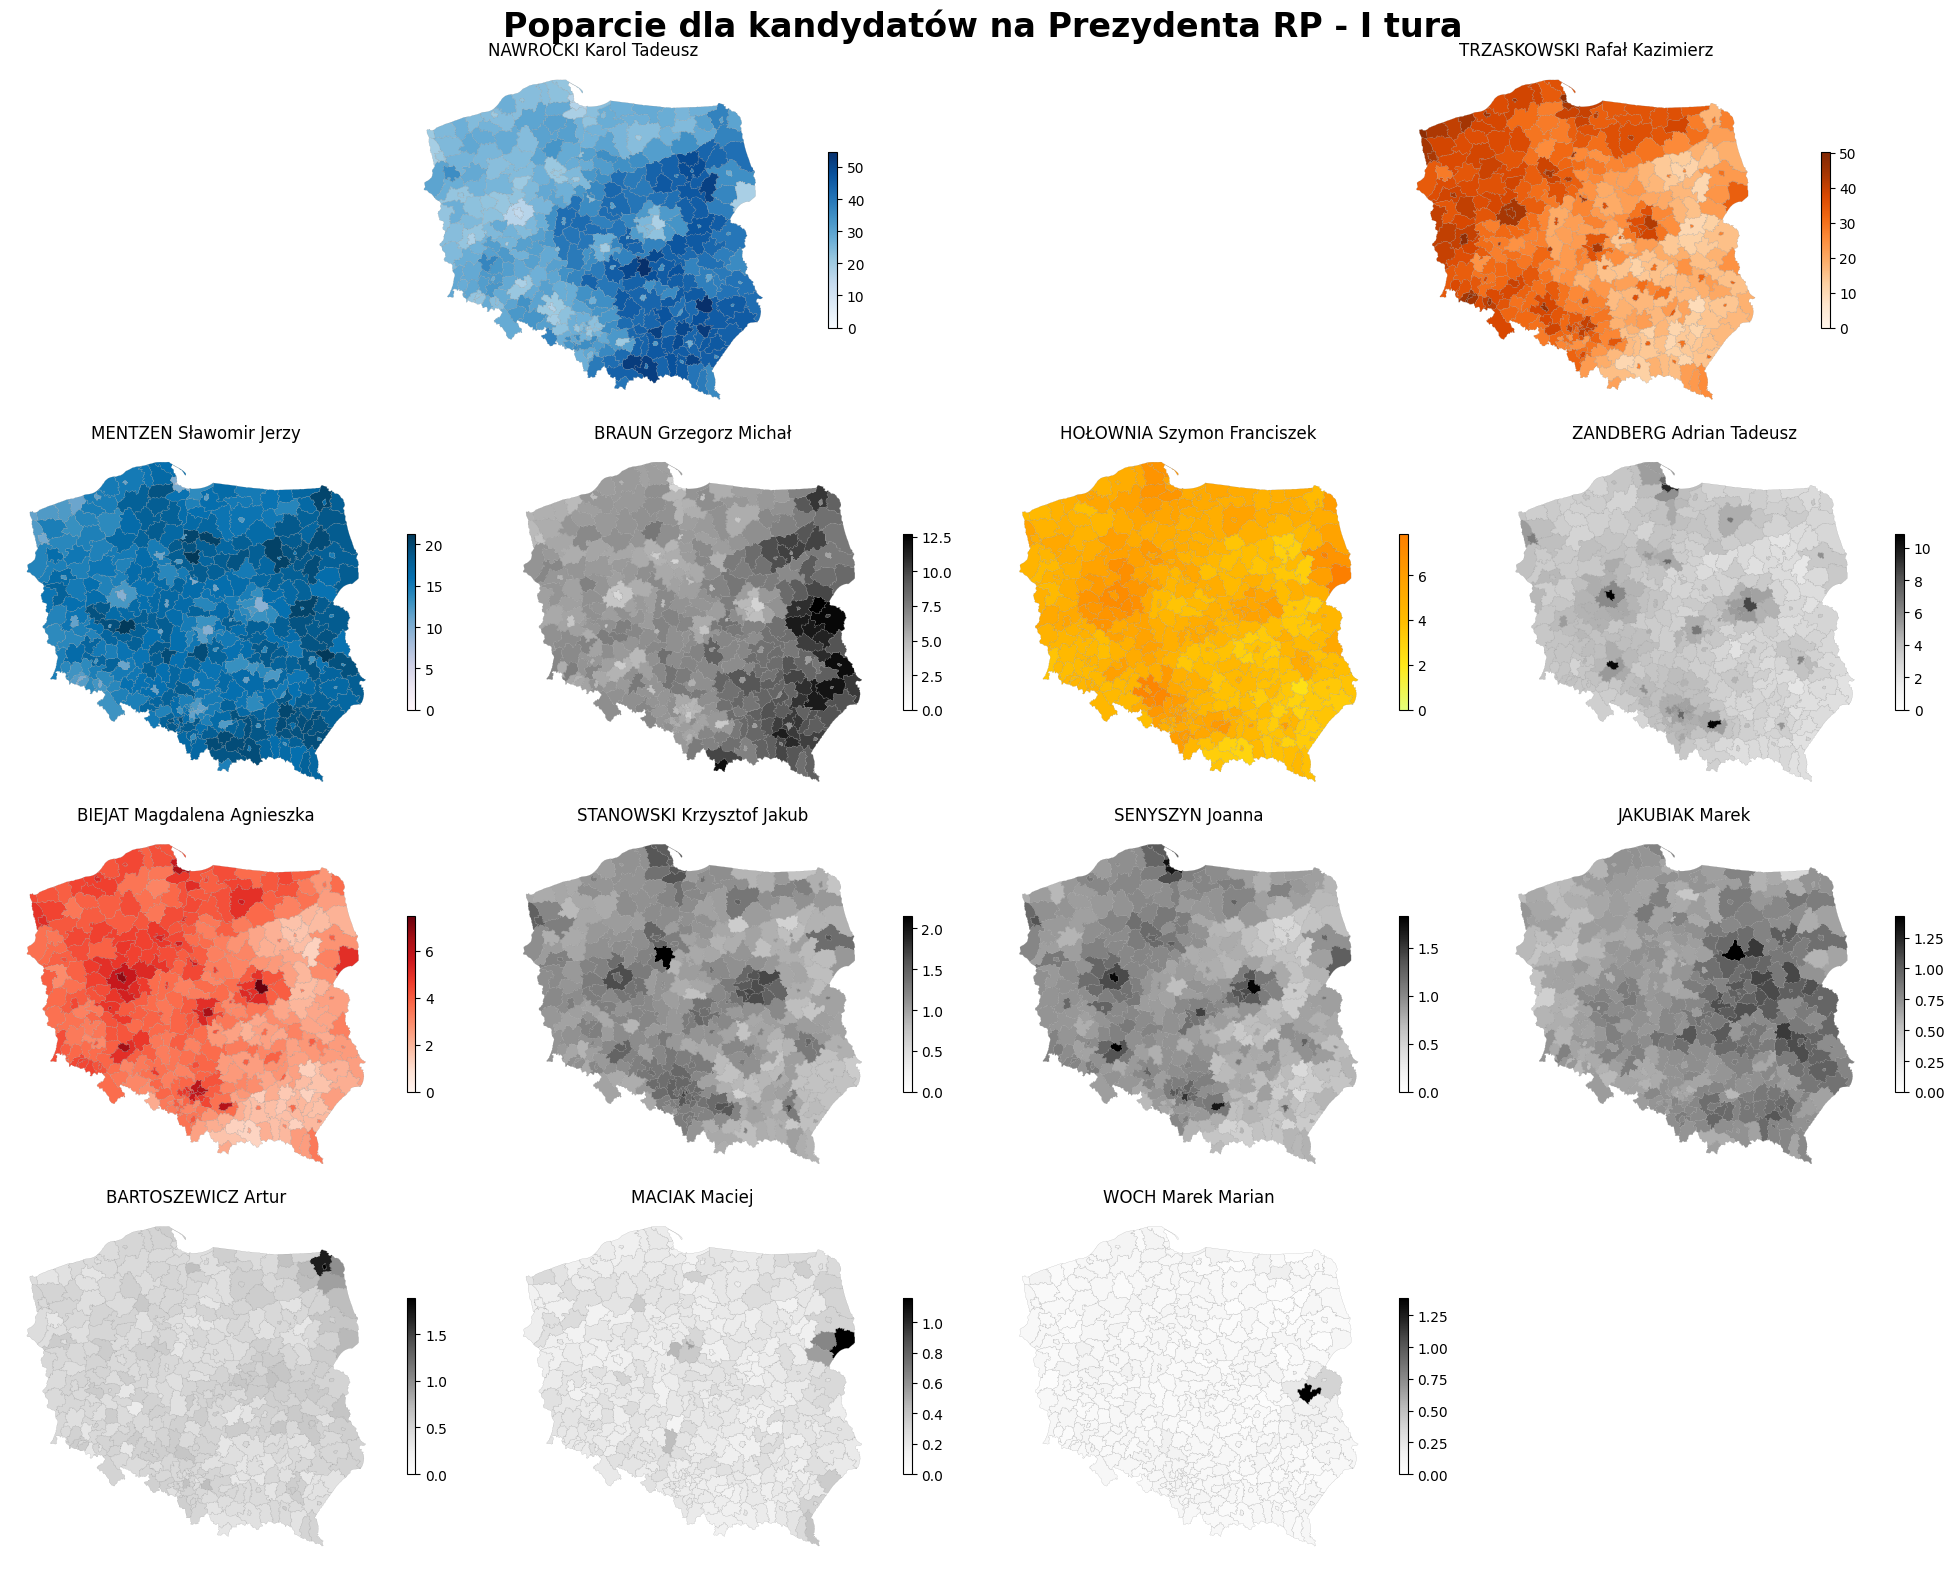

In [15]:
import matplotlib.pyplot as plt
layout = """AABB
 CDEF
 GHIJ
 KLM."""
kandydaci_sorted = gdf_merged[kandydaci].mean().sort_values(ascending=False).index.tolist()
fig, axes_dict = plt.subplot_mosaic(layout, figsize=(20, 16))
cmaps = {
    'TRZASKOWSKI Rafał Kazimierz': 'Oranges',
    'NAWROCKI Karol Tadeusz': 'Blues',
    'MENTZEN Sławomir Jerzy': 'PuBu',
    'HOŁOWNIA Szymon Franciszek': 'Wistia',
    'BIEJAT Magdalena Agnieszka': 'Reds'
}
srednie_poparcie = {kandydat: gdf_merged[f"{kandydat}_%"].mean() for kandydat in kandydaci}
kandydaci_sorted = sorted(srednie_poparcie.keys(), key=lambda k: srednie_poparcie[k], reverse=True)

# Tworzymy słownik mapujący literę z mozaiki na kandydata (dla 13 liter z układu)
litery_osi = "ABCDEFGHIJKLM"
kand_dict = dict(zip(litery_osi, kandydaci_sorted))
for litera, ax in axes_dict.items():
  if litera == '.':
    ax.axis('off')
    continue
  kandydat = kand_dict[litera]
  vmax = gdf_merged[f"{kandydat}_%"].max()

  # Use .get() to provide a default colormap if the candidate is not in cmaps
  cmap_to_use = cmaps.get(kandydat, 'Greys') # 'Greys' is a neutral default colormap

  gdf_merged.plot(ax=ax, column=f"{kandydat}_%", cmap=cmap_to_use, vmin=0, vmax=vmax,
                  legend = True, legend_kwds={'shrink': 0.5}, edgecolor='gray', linewidth=0.1)
  ax.axis('off')
  ax.set_title(kandydat)
fig.suptitle("Poparcie dla kandydatów na Prezydenta RP - I tura", fontsize=24, fontweight='bold')
plt.tight_layout()
plt.show()

## Zadanie 3: Ideologia w przestrzeni – Mapowanie Nurtów
---

Teraz zgrupujemy kandydatów w trzy główne nurty: **Lewicę** (odcienie czerwieni), **Centrum** (odcienie żółci/pomarańczy) i **Prawicę** (odcienie niebieskości). Użyjemy subtelnych konturów powiatów (`linewidth=0.1`), aby nie dominowały nad samymi danymi.

**Instrukcja krok po kroku:**
1. Stwórz listy nazw kandydatów przypisanych do nurtów (Lewica, Centrum, Prawica).
2. Zsumuj wyniki kandydatów z danej listy w poziomie (`gdf_merged[lista].sum(axis=1)`), podziel przez sumę wszystkich głosów i pomnóż przez 100, tworząc kolumny `Poparcie_Lewica_%`, `Poparcie_Centrum_%`, `Poparcie_Prawica_%`.
3. Zainicjuj płótno z 3 wykresami w jednym rzędzie: `fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))`.
4. Narysuj 3 kartogramy. **Ważne:** Dla każdej mapy oblicz indywidualny `vmax` na podstawie maksymalnej wartości w danej kolumnie (np. `vmax = gdf_merged['Poparcie_Lewica_%'].max()`).
   * **Lewica (ax1):** `cmap='Reds'`.
   * **Centrum (ax2):** `cmap='YlOrBr'` (Yellow-Orange-Brown - lepiej oddaje ideę centrum).
   * **Prawica (ax3):** `cmap='Blues'`.
5. Ustaw `edgecolor='gray'` oraz bardzo cienką linię `linewidth=0.1` (to sprawi, że mapa będzie wyglądać jak "mgła danych", a nie "jigsaw puzzle").
6. Dodaj legendy (`legend=True`), wyłącz osie (`ax.axis('off')`) i nadaj tytuły.

In [16]:
kandydaci

['BARTOSZEWICZ Artur',
 'BIEJAT Magdalena Agnieszka',
 'BRAUN Grzegorz Michał',
 'HOŁOWNIA Szymon Franciszek',
 'JAKUBIAK Marek',
 'MACIAK Maciej',
 'MENTZEN Sławomir Jerzy',
 'NAWROCKI Karol Tadeusz',
 'SENYSZYN Joanna',
 'STANOWSKI Krzysztof Jakub',
 'TRZASKOWSKI Rafał Kazimierz',
 'WOCH Marek Marian',
 'ZANDBERG Adrian Tadeusz']

In [17]:
gdf_merged

,teryt_powiatu,geometry,teryt,nazwa,podpowiedz,typ,parent_id,TERYT Powiatu,Powiat,Województwo,...,HOŁOWNIA Szymon Franciszek_%,JAKUBIAK Marek_%,MACIAK Maciej_%,MENTZEN Sławomir Jerzy_%,NAWROCKI Karol Tadeusz_%,SENYSZYN Joanna_%,STANOWSKI Krzysztof Jakub_%,TRZASKOWSKI Rafał Kazimierz_%,WOCH Marek Marian_%,ZANDBERG Adrian Tadeusz_%
0,0201,"POLYGON ((15.48876 51.17614, 15.47992 51.1756,...",0201022,Bolesławiec,"gm. Bolesławiec, pow. bolesławiecki, woj. doln...",gmi,0201,20100.0,bolesławiecki,dolnośląskie,...,4.161645,0.568168,0.221364,16.479327,28.494478,0.919891,1.111740,33.556337,0.103303,3.741053
1,0202,"POLYGON ((16.54846 50.63915, 16.5478 50.64244,...",0202033,Pieszyce,"gm. Pieszyce, pow. dzierżoniowski, woj. dolnoś...",gmi,0202,20200.0,dzierżoniowski,dolnośląskie,...,3.982219,0.587314,0.161223,13.966558,29.849371,0.891335,1.112442,35.312543,0.066793,3.540006
2,0203,"POLYGON ((16.08609 51.61075, 16.08248 51.60524...",0203011,Głogów,"gm. Głogów, pow. głogowski, woj. dolnośląskie",gmi,0203,20300.0,głogowski,dolnośląskie,...,4.686967,0.672351,0.187576,14.292326,30.562728,0.857491,1.108404,33.600487,0.080390,4.248477
3,0204,"POLYGON ((16.61844 51.51784, 16.60928 51.51716...",0204022,Jemielno,"gm. Jemielno, pow. górowski, woj. dolnośląskie",gmi,0204,20400.0,górowski,dolnośląskie,...,3.920459,0.799660,0.240606,17.231618,32.354398,0.927040,0.941193,27.598896,0.084920,3.828462
4,0205,"POLYGON ((16.1672 50.94543, 16.17447 50.93852,...",0205011,Jawor,"gm. Jawor, pow. jaworski, woj. dolnośląskie",gmi,0205,20500.0,jaworski,dolnośląskie,...,4.149982,0.605206,0.195668,14.770659,33.063342,0.837277,1.010193,30.387696,0.118311,3.635784
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,3217,"POLYGON ((16.3554 53.11317, 16.35275 53.10275,...",3217052,Wałcz,"gm. Wałcz, pow. wałecki, woj. zachodniopomorskie",gmi,3217,321700.0,wałecki,zachodniopomorskie,...,4.972425,0.684932,0.128981,14.499199,23.505604,0.965131,1.058531,39.325743,0.111190,3.940580
376,3218,"POLYGON ((15.71359 53.55435, 15.71054 53.55176...",3218043,Resko,"gm. Resko, pow. łobeski, woj. zachodniopomorskie",gmi,3218,321800.0,łobeski,zachodniopomorskie,...,4.849185,0.541204,0.259778,13.241449,29.196132,0.923654,0.822630,36.556502,0.064944,3.254438
377,3261,"POLYGON ((16.19235 54.26929, 16.19353 54.26437...",3261011,Koszalin,"gm. Koszalin, pow. Koszalin, woj. zachodniopom...",gmi,3261,326100.0,Koszalin,zachodniopomorskie,...,5.422558,0.625012,0.167827,11.593588,20.642759,1.132352,1.250024,45.099250,0.098382,3.711491
378,3262,"MULTIPOLYGON (((14.78866 53.34752, 14.80501 53...",3262011,Szczecin,"gm. Szczecin, pow. Szczecin, woj. zachodniopom...",gmi,3262,326200.0,Szczecin,zachodniopomorskie,...,5.014251,0.666088,0.140963,10.653799,20.964227,1.355929,1.516513,43.278187,0.085714,6.355206


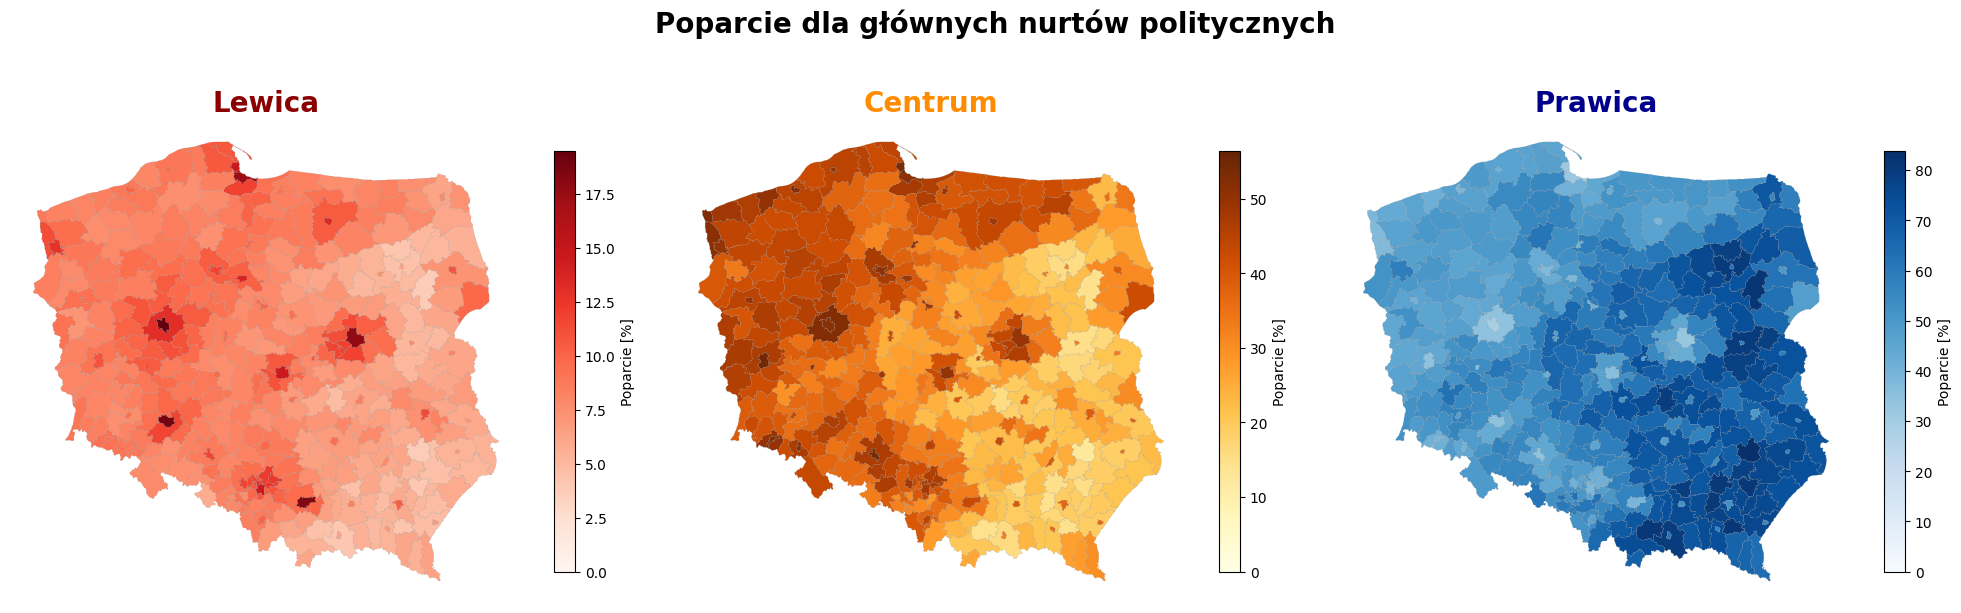

In [20]:
# @title Miejsce na Twój kod
lewica = [
    'BIEJAT Magdalena Agnieszka',
    'SENYSZYN Joanna',
    'ZANDBERG Adrian Tadeusz'
]

centrum = [
    'HOŁOWNIA Szymon Franciszek',
    'TRZASKOWSKI Rafał Kazimierz',
    'STANOWSKI Krzysztof Jakub'
]

prawica = [
    'BARTOSZEWICZ Artur',
    'BRAUN Grzegorz Michał',
    'JAKUBIAK Marek',
    'MACIAK Maciej',
    'MENTZEN Sławomir Jerzy',
    'NAWROCKI Karol Tadeusz',
    'WOCH Marek Marian'
]

suma = gdf_merged[kandydaci].sum(axis=1)
gdf_merged['Poparcie_Lewica_%'] = (gdf_merged[lewica].sum(axis=1) / suma) * 100
gdf_merged['Poparcie_Centrum_%'] = (gdf_merged[centrum].sum(axis=1) / suma) * 100
gdf_merged['Poparcie_Prawica_%'] = (gdf_merged[prawica].sum(axis=1) / suma) * 100
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Poparcie dla głównych nurtów politycznych", fontsize=20, fontweight='bold', y=1.05)
mapy = [
    ('Lewica', 'Poparcie_Lewica_%', 'Reds', ax1, 'darkred'),
    ('Centrum', 'Poparcie_Centrum_%', 'YlOrBr', ax2, 'darkorange'),
    ('Prawica', 'Poparcie_Prawica_%', 'Blues', ax3, 'darkblue')
]

for tytul, kolumna, paleta, ax, kolor_tytulu in mapy:
    vmax = gdf_merged[kolumna].max()

    gdf_merged.plot(
        ax=ax,
        column=kolumna,
        cmap=paleta,
        vmin=0,
        vmax=vmax,
        legend=True,
        legend_kwds={'shrink': 0.8, 'label': 'Poparcie [%]'},
        edgecolor='gray',
        linewidth=0.1
    )

    ax.set_title(
        tytul,
        fontsize=20,
        fontweight='bold',
        color=kolor_tytulu
    )
    ax.axis('off')

plt.tight_layout()
plt.show()



## Zadania dodatkowe dla chętnych: Wizualny Mianownik i Walka z Przestrzenią
---

W tej sekcji przeprowadzimy **radykalną dekonstrukcję** map wyborczych na podstawie wizji W. Rankina.

### Zadanie Dodatkowe A: Problem "Pustych Hektarów" (Visual Denominator)
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 3 "People", s. 134-136).*

Rankin ostro krytykuje standardowe mapy terytorialne, nazywając je "ruralizującymi" (faworyzującymi wieś). Zalesiony powiat na wschodzie w tradycyjnym kartogramie wizualnie "przekrzykuje" Warszawę, chociaż w Warszawie oddano dziesiątki razy więcej głosów.
Zmieńmy **Wizualny Mianownik (Visual Denominator)**. Zamiast kolorować ziemię, narysujmy siłę głosu obywateli.

Stwórz wykres bąbelkowy (punktowy). Użyj `gdf.geometry.centroid`, by znaleźć środki ciężkości powiatów. Narysuj na mapie zarysów dwa nachodzące na siebie "morza" kropek (najpierw niebieskie bąble Prawicy, potem pomarańczowe bąble Centrum). Ich rozmiar (`s=...`) niech odpowiada **ABSOLUTNEJ sumie oddanych głosów** na dany nurt (zsumowane wartości ze zdefiniowanych wcześniej list), a nie procentom. Pamiętaj, aby zmniejszyć kropki proporcjonalnie w Matplotlib, dzieląc zmienną rozmiaru przez np. 500. Zobacz, jak potężne stają się nagle miasta!

### Zadanie Dodatkowe B: Obalenie "Zwycięzca bierze wszystko" (Koniec z Puzzlami)
---

*(Inspiracja: Rankin, W. "Radical Cartography", Rozdział 1 "Boundaries", s. 57-60).*

Często widzimy mapy pokazujące po prostu "kto wygrał dany powiat", dzieląc kraj na dwie nienawidzące się połówki. Tworzy to iluzję twardych granic kulturowych.

Mając do dyspozycji wygenerowane wyżej centroidy bąbli, **wyrzuć całkowicie mapę bazową (kontury) pod spodem**. Narysuj kropki "zawieszone w powietrzu".
* Wielkość kropki to całkowita siła zsumowana (wszyscy głosujący w ogóle w powiecie).
* Kolor kropki (przekazywany argumentem `c=`) zależy od tego, czy w danym powiecie zwyciężyło łącznie Centrum czy zsumowana Prawica.
Zauważysz, jak "twarde granice polityczne" Polski ulegają rozmyciu.

/tmp/ipykernel_15231/2617064004.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_merged['srodek'] = gdf_merged.geometry.centroid


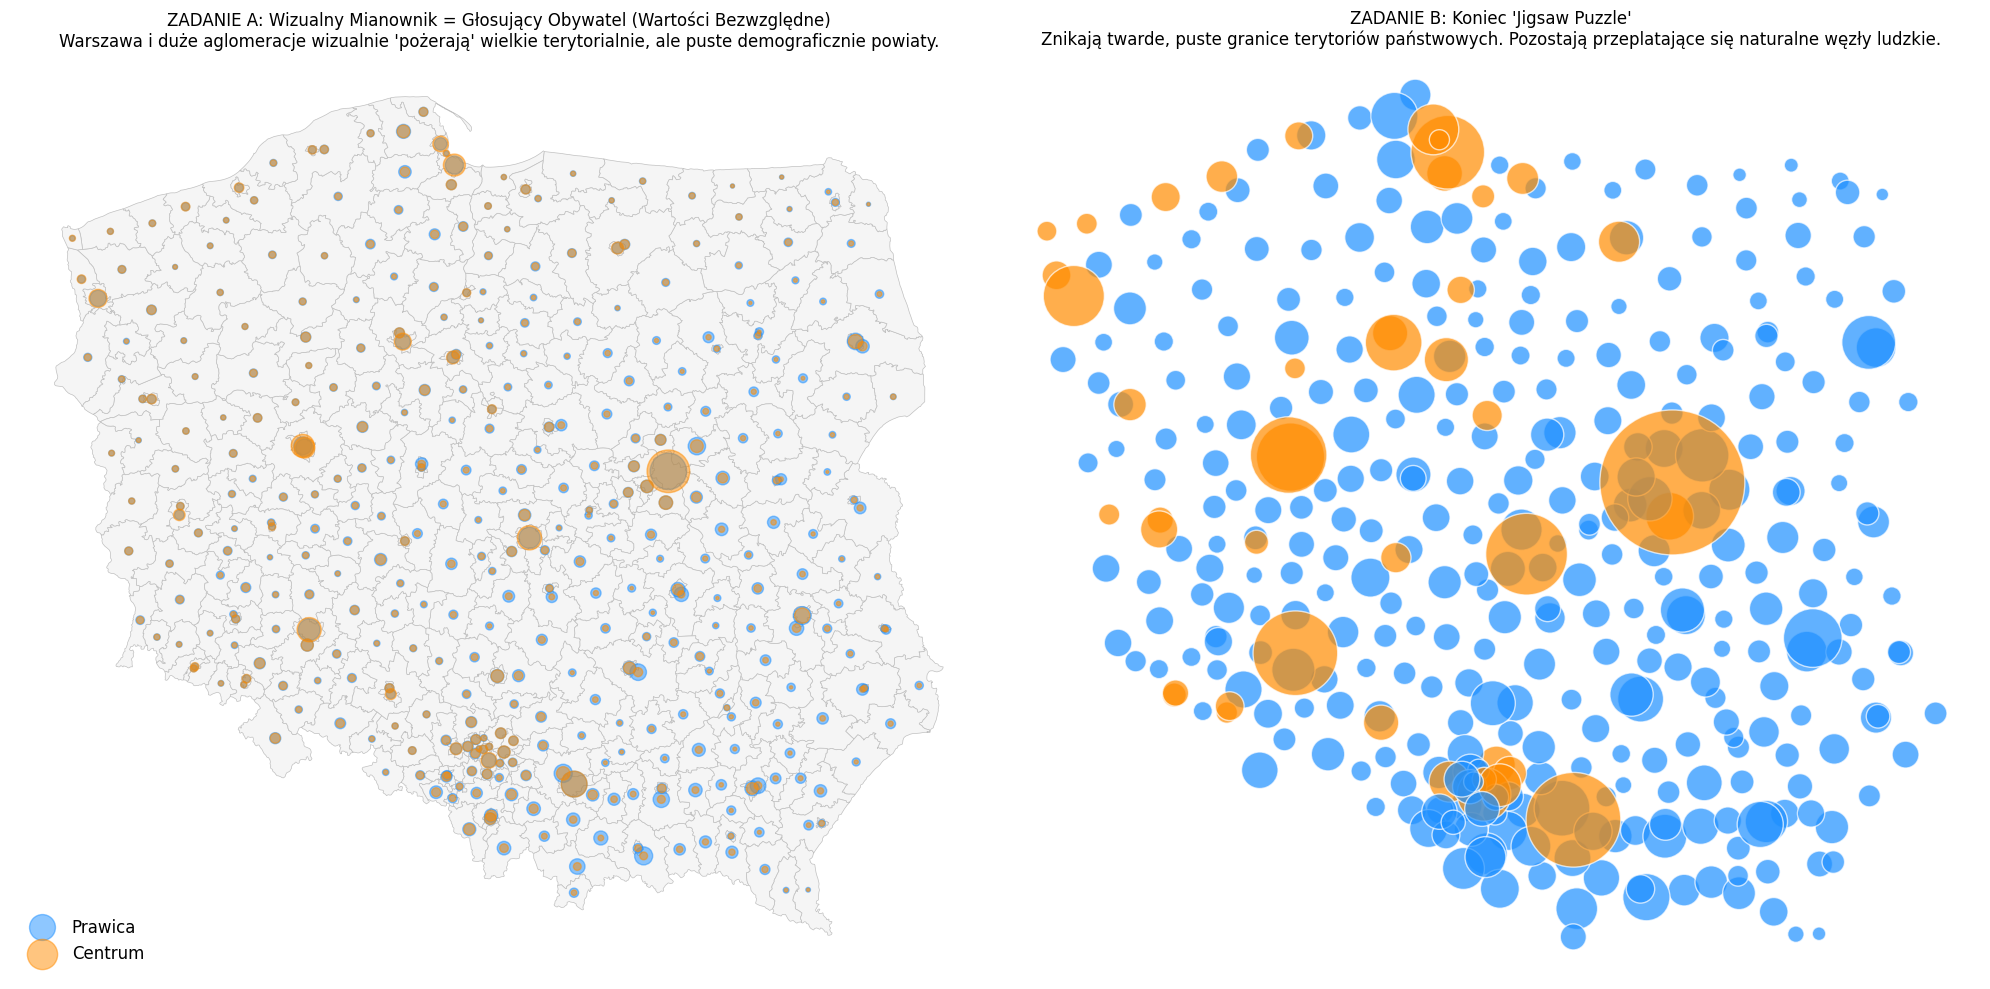

In [ ]:
# @title Miejsce na Twój kod